In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df_raw = pd.read_csv("crop_yield.csv")

print(df_raw.head())
print(df_raw.shape)
print(df_raw.info())
print(df_raw.isnull().sum())

# EDA yaha kare
df_raw.groupby('Crop')['Yield'].mean()

           Crop  Crop_Year       Season  State     Area  Annual_Rainfall  \
0      Arecanut       1997  Whole Year   Assam  73814.0           2051.4   
1     Arhar/Tur       1997  Kharif       Assam   6637.0           2051.4   
2   Castor seed       1997  Kharif       Assam    796.0           2051.4   
3      Coconut        1997  Whole Year   Assam  19656.0           2051.4   
4  Cotton(lint)       1997  Kharif       Assam   1739.0           2051.4   

   Fertilizer  Pesticide     Yield  Avg_Temperature  
0  7024878.38   22882.34     0.796           23.692  
1   631643.29    2057.47     0.710           23.692  
2    75755.32     246.76     0.238           23.692  
3  1870661.52    6093.36  5238.052           23.692  
4   165500.63     539.09     0.421           23.692  
(19689, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19689 entries, 0 to 19688
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   C

Crop
Arecanut                    2.073617
Arhar/Tur                   0.967343
Bajra                       2.427456
Banana                     26.851143
Barley                      1.595525
Black pepper                0.829635
Cardamom                    0.168405
Cashewnut                   3.120455
Castor seed                 0.693623
Coconut                  8652.000215
Coriander                   0.648186
Cotton(lint)                1.797042
Cowpea(Lobia)               0.813224
Dry chillies                2.078356
Garlic                      4.544880
Ginger                      6.442226
Gram                        0.876471
Groundnut                   1.360988
Guar seed                   0.951825
Horse-gram                  0.462830
Jowar                       1.072499
Jute                        7.555398
Khesari                     0.788920
Linseed                     0.473932
Maize                       3.427209
Masoor                      0.703111
Mesta                       5.389

In [4]:
df_raw['Yield'] = df_raw['Yield'].apply(lambda x: x * 1000 if x < 100 else x)

print(df_raw['Yield'].describe())

count    19689.000000
mean      4103.155895
std      10506.908798
min          0.000000
25%        597.000000
50%       1026.000000
75%       2364.000000
max      99782.000000
Name: Yield, dtype: float64


In [5]:
df = df_raw.copy()

df = pd.get_dummies(df, columns=['Crop','State','Season'])

In [7]:
X = df.drop('Yield', axis=1)
y = df['Yield']

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape, X_test.shape)

(15751, 97) (3938, 97)



RANDOM FOREST
MAE: 714.1886262392078
MSE: 7928650.276854808
RMSE: 2815.7859074963085
R2: 0.9296880699890319


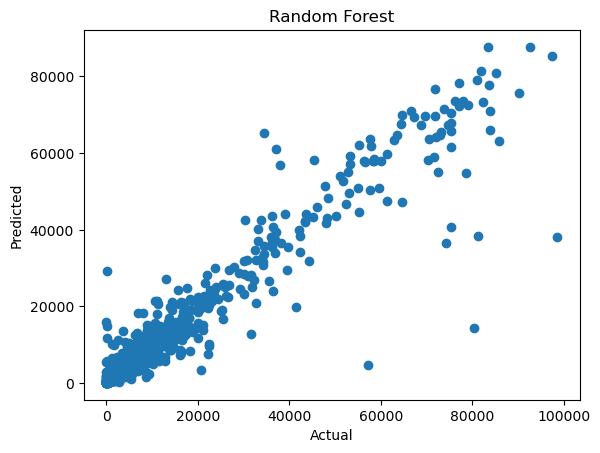

In [11]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

rf = RandomForestRegressor()
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("\nRANDOM FOREST")
print("MAE:", mae_rf)
print("MSE:", mse_rf)
print("RMSE:", rmse_rf)
print("R2:", r2_rf)

# Excel
rf_df = X_test.copy()
rf_df['Actual_Yield'] = y_test
rf_df['Predicted_RF'] = y_pred_rf
rf_df.to_excel("Random_Forest_Output.xlsx", index=False)

# Graph
plt.scatter(y_test, y_pred_rf)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Random Forest")
plt.show()

In [13]:
pairs = [
    ('Rice', 'West Bengal'),
    ('Maize', 'Uttar Pradesh'),
    ('Gram', 'Madhya Pradesh'),
    ('Potato', 'Punjab')
]

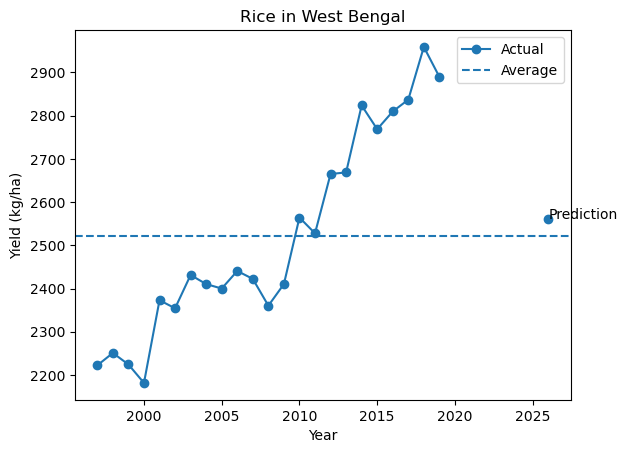

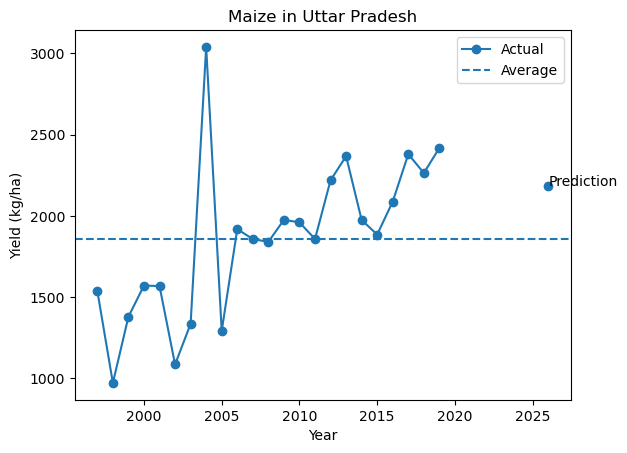

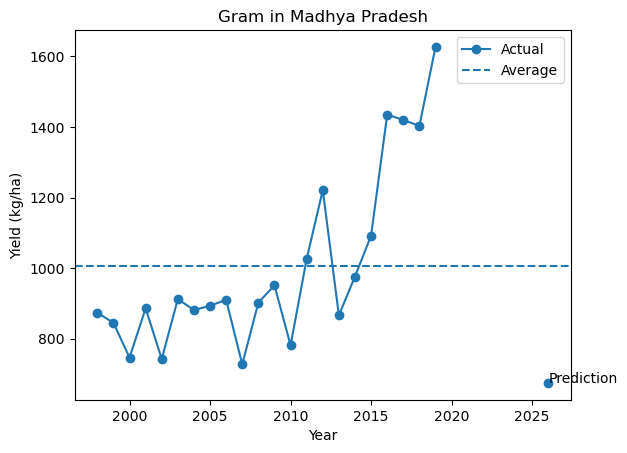

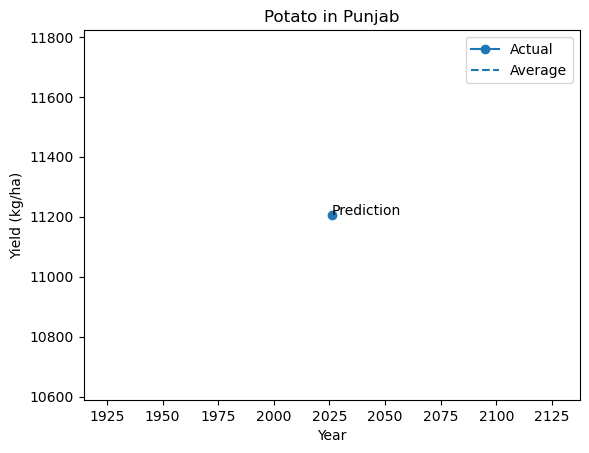

In [14]:
import matplotlib.pyplot as plt

for crop, state in pairs:
    
    data = df_raw[(df_raw['Crop'] == crop) & (df_raw['State'] == state)]
    
    yearly = data.groupby('Crop_Year')['Yield'].mean().reset_index()
    
    avg_yield = yearly['Yield'].mean()
    
    # 👉 Prediction input (adjust values realistic rakh)
    input_data = {
        'Crop': crop,
        'Season': 'Kharif',
        'State': state,
        'Crop_Year': 2026,
        'Area': 4000,
        'Annual_Rainfall': 1000,
        'Fertilizer': 80000,
        'Pesticide': 150,
        'Avg_Temperature': 25
    }
    
    input_df = pd.DataFrame([input_data])
    input_df = pd.get_dummies(input_df)
    input_df = input_df.reindex(columns=X.columns, fill_value=0)
    
    prediction = rf.predict(input_df)[0]
    
    # 🔥 GRAPH
    plt.figure()
    
    # Actual trend
    plt.plot(yearly['Crop_Year'], yearly['Yield'], marker='o', label='Actual')
    
    # Average line
    plt.axhline(avg_yield, linestyle='--', label='Average')
    
    # Prediction point
    plt.scatter(2026, prediction)
    plt.text(2026, prediction, "Prediction")
    
    plt.title(f"{crop} in {state}")
    plt.xlabel("Year")
    plt.ylabel("Yield (kg/ha)")
    plt.legend()
    
    plt.show()